<a href="https://colab.research.google.com/github/PrashantBagri/IP_IIIT_Delhi_2026/blob/main/FMNIST_discretize_all.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


In [3]:
# Normalize (important)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten images (28x28 → 784)
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

print(x_train.shape)

(60000, 784)


In [4]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)


model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    x_train, y_train,
    epochs=60,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7701 - loss: 0.6791 - val_accuracy: 0.8248 - val_loss: 0.5134
Epoch 2/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8510 - loss: 0.4233 - val_accuracy: 0.8618 - val_loss: 0.3968
Epoch 3/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8659 - loss: 0.3784 - val_accuracy: 0.8647 - val_loss: 0.3731
Epoch 4/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8741 - loss: 0.3490 - val_accuracy: 0.8727 - val_loss: 0.3557
Epoch 5/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8805 - loss: 0.3268 - val_accuracy: 0.8587 - val_loss: 0.3836
Epoch 6/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8904 - loss: 0.3045 - val_accuracy: 0.8725 - val_loss: 0.3498
Epoch 7/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8912 - loss: 0.2941 - val_accuracy: 0.8768 - val_loss: 0.3383
Epoch 8/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8984 - loss: 0.2789 - val_accuracy: 0.

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8835 - loss: 0.5545
Test accuracy: 0.8834999799728394


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 334,544 (1.28 MB)

 Trainable params: 111,514 (435.60 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 223,030 (871.21 KB)

In [9]:

import matplotlib.pyplot as plt

dense_layers = []

for layer in model.layers:

    if isinstance(layer, keras.layers.Dense):
        dense_layers.append(layer)


w0 = dense_layers[0].get_weights()[0]
w1 = dense_layers[1].get_weights()[0]
w2 = dense_layers[2].get_weights()[0]
w3 = dense_layers[3].get_weights()[0]

b0 = dense_layers[0].get_weights()[1]
b1 = dense_layers[1].get_weights()[1]
b2 = dense_layers[2].get_weights()[1]
b3 = dense_layers[3].get_weights()[1]

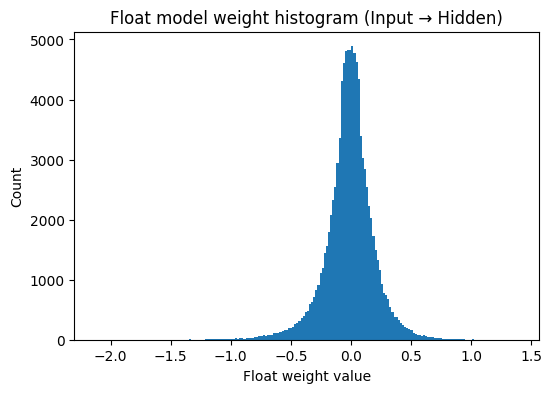

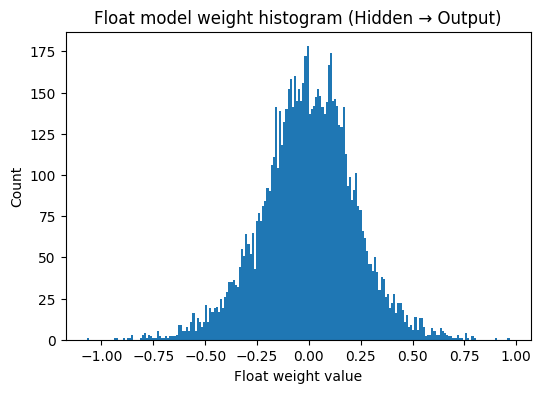

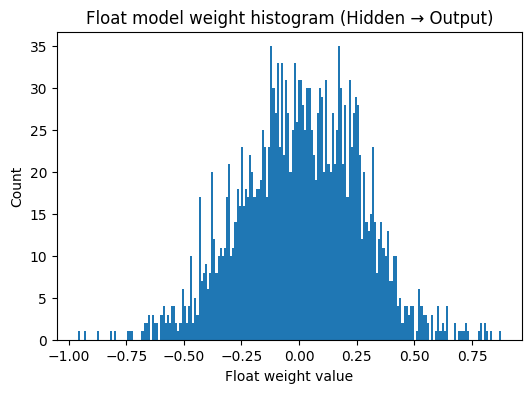

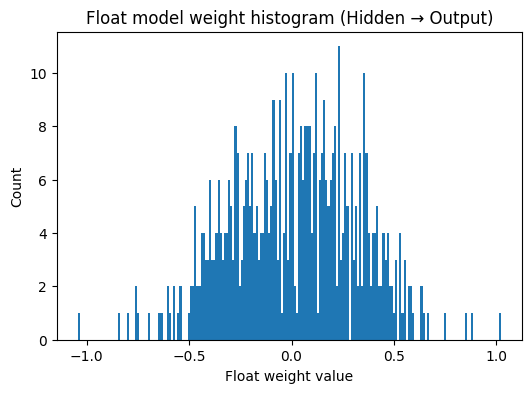

In [10]:
w0_plot = dense_layers[0].get_weights()[0].reshape(-1)
plt.figure(figsize=(6, 4))
plt.hist(w0_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
# plt.xlim([-4, 4])
plt.show()

w1_plot = dense_layers[1].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w1_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → Output)")
# plt.xlim([-4, 4])
plt.show()

w2_plot = dense_layers[2].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w2_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → Output)")
# plt.xlim([-4, 4])
plt.show()

w3_plot = dense_layers[3].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w3_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → Output)")
# plt.xlim([-4, 4])
plt.show()


In [11]:
# print(f"\n\n{w0}\n\n{w1}\n\n{w2}\n\n{w3}\n\n")

w2.ndim
# w1
# w2
# w3

2

In [12]:

# levels1 = [-1.0 , -0.75, -0.25, 0.0 , 0.25, 0.75, 1.0]
levels = [-1.0 , -0.75, -0.25, 0.0 , 0.25, 0.75, 1.0]


def snap_weights_to_levels(weights, levels):


    levels = np.array(levels)
    snapped = np.zeros_like(weights)

    for i in range(weights.shape[0]):
        for j in range(weights.shape[1]):
            w = weights[i, j]


            if w <= levels[0]:
                snapped[i, j] = levels[0]
                continue
            if w >= levels[-1]:
                snapped[i, j] = levels[-1]
                continue


            for k in range(len(levels) - 1):
                low = levels[k]
                high = levels[k + 1]

                if low <= w <= high:
                    midpoint = (low + high) / 2

                    if w > midpoint:
                        snapped[i, j] = high
                    else:
                        snapped[i, j] = low
                    break

    return snapped


In [13]:
snapped_w0 = snap_weights_to_levels(w0, levels)
snapped_w1 = snap_weights_to_levels(w1, levels)
snapped_w2 = snap_weights_to_levels(w2, levels)
snapped_w3 = snap_weights_to_levels(w3, levels)

# snapped_w0 = snap_weights_to_levels(w0, levels).reshape(w0.shape)
# snapped_w1 = snap_weights_to_levels(w1, levels).reshape(w1.shape)
# snapped_w2 = snap_weights_to_levels(w2, levels).reshape(w2.shape)
# snapped_w3 = snap_weights_to_levels(w3, levels).reshape(w3.shape)

snapped_w0
snapped_w1
snapped_w2
snapped_w3



array([[ 1.  ,  0.25,  0.25, -0.25,  0.  ,  0.  , -0.75, -0.25,  0.25,
        -0.25,  0.  ,  0.75,  0.25,  0.25, -0.25,  0.  ],
       [ 0.  ,  0.  ,  0.25, -0.75,  0.25,  0.  ,  0.  , -0.25,  0.75,
        -0.75,  0.25, -0.25,  0.25, -0.25, -0.25,  0.  ],
       [ 0.  , -0.25,  0.25,  0.25,  0.25,  0.25, -0.25, -0.25,  0.25,
         0.  , -0.25,  0.  ,  0.25,  0.  ,  0.25, -0.25],
       [ 0.  ,  0.75,  0.25, -0.25,  0.25,  0.75,  0.25, -0.25,  0.25,
         0.  ,  0.25,  0.  ,  0.  ,  0.25,  0.  ,  0.  ],
       [ 0.25, -0.75,  0.  ,  0.  ,  0.25, -0.25,  0.  ,  0.  , -0.25,
        -0.25,  0.25, -0.25,  0.25,  0.25,  0.25, -0.25],
       [ 0.25,  0.  ,  0.75, -0.25, -0.25, -0.25,  0.  , -0.25, -0.25,
         0.25, -0.25,  0.  ,  0.25,  0.25,  0.  ,  0.25],
       [ 0.75,  0.75, -0.25,  0.  , -0.25, -0.25,  0.25, -0.25, -0.75,
         0.25, -0.25, -0.25,  0.75,  0.25, -0.25,  0.25],
       [ 0.25, -0.25,  0.25,  0.25, -0.75, -0.75,  0.  ,  0.  ,  0.  ,
         0.25, -0.25,  0. 

In [14]:
# snapped_w0 = snap_weights_to_levels(w0, levels).reshape(w0.shape)
# snapped_w1 = snap_weights_to_levels(w1, levels).reshape(w1.shape)
# snapped_w2 = snap_weights_to_levels(w2, levels).reshape(w2.shape)
# snapped_w3 = snap_weights_to_levels(w3, levels).reshape(w3.shape)

dense_layers[0].set_weights([snapped_w0, b0])
dense_layers[1].set_weights([snapped_w1, b1])
dense_layers[2].set_weights([snapped_w2, b2])
dense_layers[3].set_weights([snapped_w3, b3])



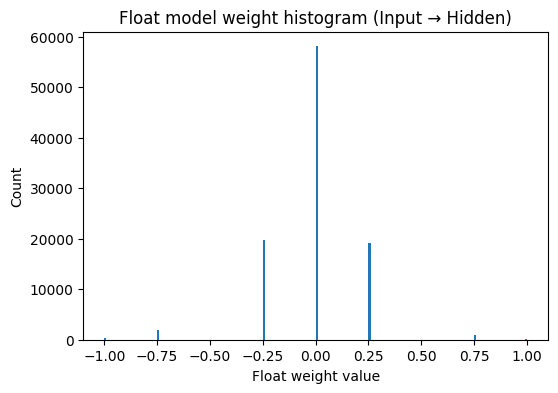

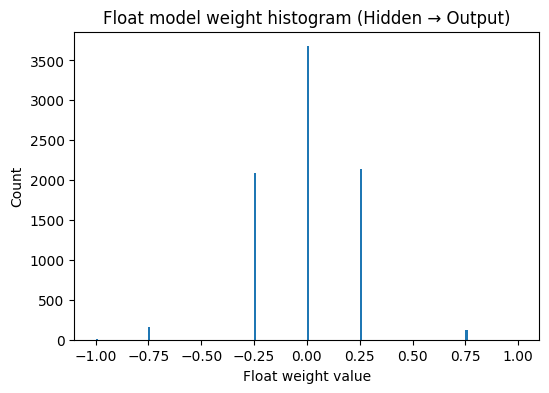

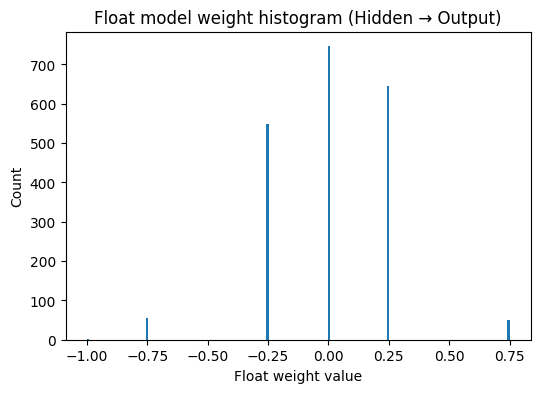

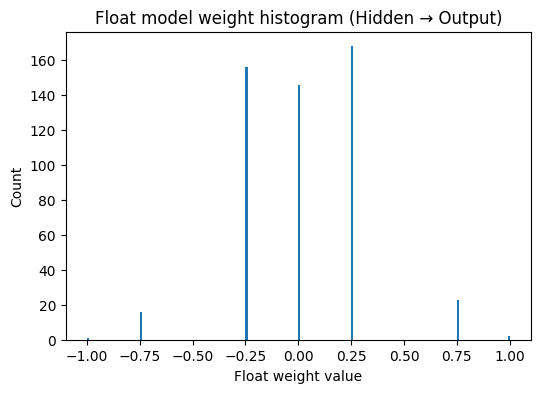

In [15]:
w0_plot = dense_layers[0].get_weights()[0].reshape(-1)
plt.figure(figsize=(6, 4))
plt.hist(w0_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
# plt.xlim([-4, 4])
plt.show()

w1_plot = dense_layers[1].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w1_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → Output)")
# plt.xlim([-4, 4])
plt.show()

w2_plot = dense_layers[2].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w2_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → Output)")
# plt.xlim([-4, 4])
plt.show()

w3_plot = dense_layers[3].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w3_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → Output)")
# plt.xlim([-4, 4])
plt.show()


In [16]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7898 - loss: 0.9907
Test accuracy: 0.7897999882698059


In [17]:
history = model.fit(
    x_train, y_train,
    epochs=60,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9360 - loss: 0.1727 - val_accuracy: 0.8877 - val_loss: 0.4314
Epoch 2/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9562 - loss: 0.1160 - val_accuracy: 0.8888 - val_loss: 0.4716
Epoch 3/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9600 - loss: 0.1051 - val_accuracy: 0.8875 - val_loss: 0.4701
Epoch 4/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9596 - loss: 0.1055 - val_accuracy: 0.8838 - val_loss: 0.4939
Epoch 5/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9641 - loss: 0.0938 - val_accuracy: 0.8873 - val_loss: 0.5151
Epoch 6/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9651 - loss: 0.0924 - val_accuracy: 0.8940 - val_loss: 0.5059
Epoch 7/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9668 - loss: 0.0899 - val_accuracy: 0.8880 - val_loss: 0.5183
Epoch 8/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9650 - loss: 0.0922 - val_accuracy: 0.

In [18]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8863 - loss: 0.7221
Test accuracy: 0.8863000273704529


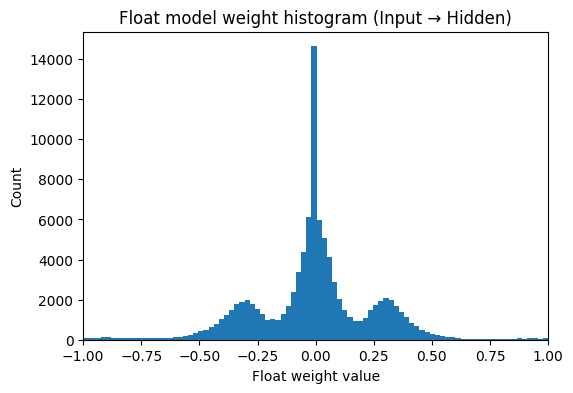

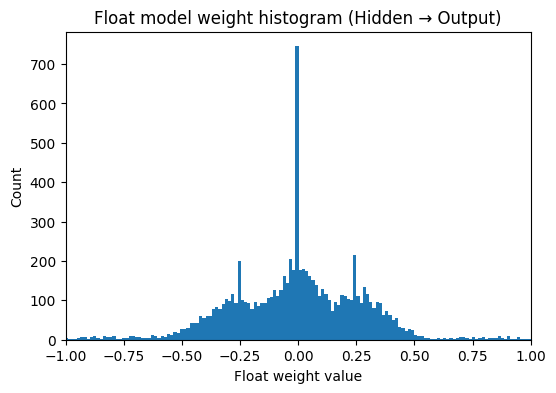

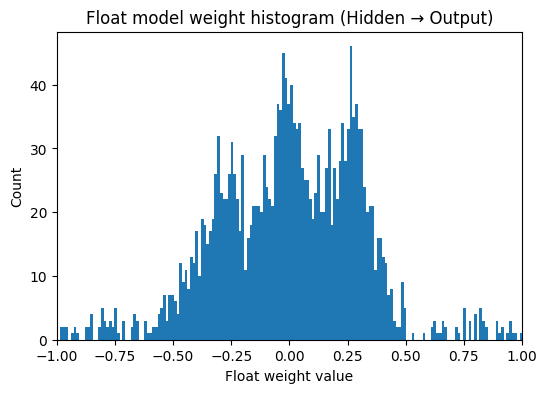

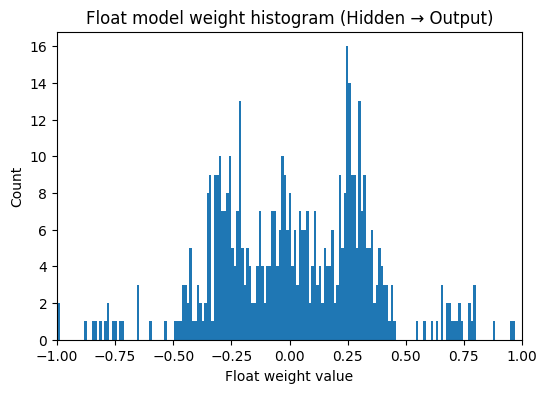

In [19]:
w2 = dense_layers[0].get_weights()[0].reshape(-1)
plt.figure(figsize=(6, 4))
plt.hist(w2, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
plt.xlim([-1, 1])
plt.show()

w2 = dense_layers[1].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w2, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → Output)")
plt.xlim([-1, 1])
plt.show()

w2 = dense_layers[2].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w2, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → Output)")
plt.xlim([-1, 1])
plt.show()
w2 = dense_layers[3].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w2, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → Output)")
plt.xlim([-1,1])
plt.show()
